# Dynamics of Role-based Passing Networks in Elite Football

MSc Data Science Dissertation - INM363 Individual Project
City St George's, University of London

Supervisor: Dr Gennady Andrienko

## Overview
Analysis of role-based passing networks using the Wyscout public event dataset (Pappalardo et al., 2019). Case study: Manchester City, Premier League 2017/18.

RQ1: Cluster role-based passing networks into tactical variants (UMAP/t-SNE)

RQ2: How do variants evolve across a season?

RQ3: Are variants associated with match outcomes?

## Data Loading & Preparation

In [1]:
#First we import some major libraries

import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from data_loading import(
load_events, load_matches, load_players, load_teams,
get_team_id, filter_matches_for_team, filter_events_for_team,
sanity_check_matches, load_raw_matches,

)
from possession_episodes import segment_season, apply_episode_threshold

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

TEAM_NAME = 'Manchester City'
COMPETITION = 'England'
EXPECTED_N_MATCHES = 38

In [2]:
#This 4 lines load all four raw Wyscout files into pandas dataframes using the functions
#from data_loading.py

teams = load_teams()
players = load_players()
matches = load_matches(competition=COMPETITION)
events = load_events(competition=COMPETITION)

print('teams:', teams.shape)
print('players:', players.shape)
print('matches:', matches.shape)
print('events:', events.shape)

teams: (142, 9)
players: (3603, 22)
matches: (380, 233)
events: (65814, 12)


In [3]:
#Now since we are only focused on Manchester City, we lookup for its ID from teams table

team_id = get_team_id(teams, TEAM_NAME)
print(f'{TEAM_NAME} -> wyId {team_id}')

Manchester City -> wyId 1625


In [4]:
#This block filters out of the 380-match competition table to just the matches
#Manchester City played. Sanity checks are done as well.

team_matches = filter_matches_for_team(matches, team_id)
sanity_check_matches(team_matches, expected_n_matches=EXPECTED_N_MATCHES)
team_matches[['wyId', 'label', 'dateutc', 'venue']].head()

Matches found: 38 (expected: 38)


,wyId,label,dateutc,venue
0,2500095,"Southampton - Manchester City, 0 - 1",2018-05-13 14:00:00,St. Mary's Stadium
1,2500024,"Manchester City - Brighton & Hove Albion, 3 - 1",2018-05-09 19:00:00,Etihad Stadium
2,2500085,"Manchester City - Huddersfield Town, 0 - 0",2018-05-06 12:30:00,Etihad Stadium
3,2500078,"West Ham United - Manchester City, 1 - 4",2018-04-29 13:15:00,London Stadium
4,2500065,"Manchester City - Swansea City, 5 - 0",2018-04-22 15:30:00,Etihad Stadium


In [5]:
#Similar to previous block, we filter the events for Man City

team_events = filter_events_for_team(events, team_id, match_ids=team_matches['wyId'])
print('Events involving', TEAM_NAME, ':', team_events.shape)
team_events.head()

Events involving Manchester City : (41216, 12)


,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],8325,"[{'y': 53, 'x': 49}, {'y': 51, 'x': 36}]",2499720,Pass,1625,1H,3.358676,85,178147292
1,8,Simple pass,[{'id': 1801}],105339,"[{'y': 51, 'x': 36}, {'y': 30, 'x': 28}]",2499720,Pass,1625,1H,5.108462,85,178147293
2,8,Simple pass,[{'id': 1801}],70086,"[{'y': 30, 'x': 28}, {'y': 79, 'x': 28}]",2499720,Pass,1625,1H,7.758945,85,178147294
3,8,Simple pass,[{'id': 1801}],8307,"[{'y': 79, 'x': 28}, {'y': 24, 'x': 28}]",2499720,Pass,1625,1H,11.267789,85,178147295
4,8,Simple pass,[{'id': 1801}],70086,"[{'y': 24, 'x': 28}, {'y': 52, 'x': 38}]",2499720,Pass,1625,1H,15.599964,85,178147296


## Exploratory Data Analysis

In [6]:
#Now, jumping into the EDA, we do a quick check of the data quality for missing values

missing_summary = team_events[['eventSec', 'positions', 'playerId', 'matchId']].isna().sum()
print(missing_summary)

empty_positions = team_events['positions'].apply(lambda p: len(p) == 0 if isinstance(p, list) else True)
print(f'Events with no position data: {empty_positions.sum()} / {len(team_events)}')

eventSec     0
positions    0
playerId     0
matchId      0
dtype: int64
Events with no position data: 0 / 41216


eventName
Pass                       27523
Duel                        7498
Others on the ball          3045
Free Kick                   1695
Shot                         603
Foul                         364
Interruption                 294
Save attempt                  89
Offside                       66
Goalkeeper leaving line       39
Name: count, dtype: int64


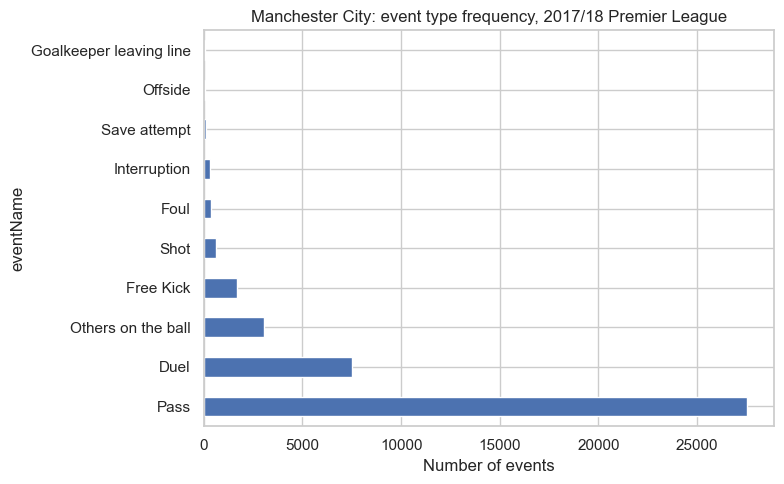

In [7]:
#Here we count the events that fall into each of the categories across all of City's events
#for the season and we create a visualisation.

event_counts = team_events["eventName"].value_counts()
print(event_counts)

fig, ax = plt.subplots(figsize=(8, 5))
event_counts.plot(kind='barh', ax=ax)
ax.set_xlabel("Number of events")
ax.set_title(f"{TEAM_NAME}: event type frequency, 2017/18 Premier League")
plt.tight_layout()
plt.savefig('event_type_frequency.png', dpi=150)
plt.show()

In [8]:
#This block isolates just the pass events and calculates the pass accuracy. So each event has a 'tags' field (a list of
#small dictionaries like "[{'id': 1801}]" ) which encode extra qualifiers about that event, rather than having a seperate
#accuracy column. The Tag ID 1801 means "accurate". The has_tag function checks whether that specific ID appears anywhere
#in a tag list of each event.

passes = team_events[team_events['eventName'] == 'Pass'].copy()

def has_tag(tags, tag_id):
    return any(t.get('id') == tag_id for t in tags) if isinstance(tags, list) else False

passes["accurate"] = passes["tags"].apply(lambda t: has_tag(t, 1801))

print(f"Total {TEAM_NAME} passes across the season: {len(passes)}")
print(f"Average passes per match: {len(passes) / EXPECTED_N_MATCHES:.1f}")
print(f"overall pass accuracy: {passes["accurate"].mean():.1%}")

Total Manchester City passes across the season: 27523
Average passes per match: 724.3
overall pass accuracy: 90.0%


## Possession Episode Segmentation

In [9]:
#The following code runs the segmentation logic from the possession_episodes.py across
#the entire season. We narrow down the result to just Man City's episodes and then apply
#the minimum-passes/duration threshold to strip out the noisy fragments.

MIN_PASSES = 2
MIN_DURATION_SECONDS = 3.0

all_segments = segment_season(events)
print(f'Total raw episodes (both teams, all {EXPECTED_N_MATCHES} matches): {len(all_segments)}')

team_segments = all_segments[all_segments['team_id'] == team_id].copy()
print(f'Raw {TEAM_NAME} episodes: {len(team_segments)}')

valid_episodes = apply_episode_threshold(
    team_segments, min_passes=MIN_PASSES, min_duration=MIN_DURATION_SECONDS
)
print(f'{TEAM_NAME} episodes after threshold (>={MIN_PASSES} passes, >={MIN_DURATION_SECONDS}s): {len(valid_episodes)}')
print(f'Retained: {len(valid_episodes) / len(team_segments):.1%}')

Total raw episodes (both teams, all 38 matches): 10787
Raw Manchester City episodes: 5397
Manchester City episodes after threshold (>=2 passes, >=3.0s): 3048
Retained: 56.5%


Valid episodes per match:
count     38.000000
mean      80.210526
std        8.862792
min       65.000000
25%       72.500000
50%       80.000000
75%       86.750000
max      100.000000
dtype: float64


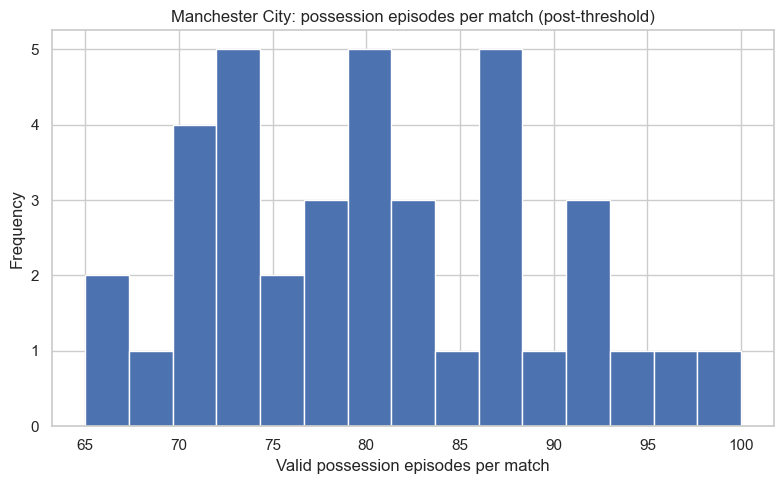

In [10]:
#Here we group the filtered episodes by match and count how many valid episodes fall in each one.
#The results are being shown in a visual

per_match = valid_episodes.groupby('matchId').size()
print('Valid episodes per match:')
print(per_match.describe())

fig, ax = plt.subplots(figsize=(8, 5))
per_match.plot(kind='hist', bins=15, ax=ax)
ax.set_xlabel('Valid possession episodes per match')
ax.set_title(f"{TEAM_NAME}: possession episodes per match (post-threshold)")
plt.tight_layout()
plt.savefig('episodes_per_match.png', dpi=150)
plt.show()

In [11]:
#save the final cleaned version of possession-episode table to disk as a csv.

valid_episodes.to_csv('city_possession_episodes.csv', index=False)
print(valid_episodes.shape)
valid_episodes.head()

(3048, 10)


,segment_id,team_id,period,start,end,n_actions,n_passes,n_events_total,duration,matchId
0,1,1625,1H,3.358676,24.312257,8,8,8,20.953581,2499720
1,9,1625,1H,63.031991,70.488325,2,2,13,7.456334,2499720
2,11,1625,1H,102.005515,189.560864,29,25,31,87.555349,2499720
3,13,1625,1H,196.406208,208.980701,7,7,10,12.574493,2499720
4,15,1625,1H,260.690678,290.389542,9,8,11,29.698864,2499720


## Step 1: Player Role Assignment

Player roles are assigned using each player's average pitch position, computed separately within time segments bounded by substitutions (so substitutes don't get treated as extra competitors alongside the players they replaced). Each of 10 outfield players is matched to one of 10 fixed reference role slots (e.g Defence-Left, Midfield-Centre, Attack-Right) using the Hungarian algorithm for optimal 1-to-1 assignment, which guarantees no two players share a role label within the same segment. Goalkeepers are identified directly from the players reference table rather than by position, since their average event location is not a reliable indicator (their distribution events can pull their average position much further upfield that their actual role).

In [12]:
from role_assignment import assign_roles_for_match, assign_roles_for_season

In [13]:
raw_matches = load_raw_matches(competition=COMPETITION)

role_assignments = assign_roles_for_season(events, raw_matches, players, team_id)
print(f"Total role assignments (across all segments, all matches): {len(role_assignments)}")

#Quick sanity check that there are no collision between player positions
collision_check = role_assignments.groupby(['matchId', 'segment_id'])['role'].apply(
    lambda r: r.duplicated().any()
)
print(f"Segments with a role collision: {collision_check.sum()} / {len(collision_check)}")

role_assignments.to_csv('city_role_assignments.csv', index=False)

Total role assignments (across all segments, all matches): 1582
Segments with a role collision: 0 / 144


## Step 2: Network Construction

Role-based passing networks are constructed at the possession-episode level (rather than per match), using the role assignments from Step 1. For each valid episode, the receiver of a pass is inferred as the next action event by the same team within that episode; a pass with no following action event (i.e. the last event in the episode) is excluded, since it has no valid same-team receiver.

Each episode's network is represented as a directed, weighted graph over a fixed set of 11 role nodes (Goalkeeper plus 10 outfield role slots), so that every episode is comparable regardless of which specific roles were involved in a given passing sequence. These networks are then flattened into fixed-length feature vectors, forming the input for the embedding and clustering steps used to answer the RQ1.

In [14]:
valid_episodes['episode_id'] = valid_episodes.index

#Here we link each episode to its role-assignment segment
valid_episodes['episode_match_seconds'] = np.where(
    valid_episodes['period'] == '1H', valid_episodes['start'], 2700 + valid_episodes['start']
)
segment_bounds = role_assignments[['matchId', 'segment_id', 'segment_start', 'segment_end']].drop_duplicates()

def find_segment(row):
    candidates = segment_bounds[
    (segment_bounds['matchId'] == row['matchId']) & 
    (segment_bounds['segment_start'] <= row['episode_match_seconds']) & 
    (row['episode_match_seconds'] < segment_bounds['segment_end'])
    ]
    return candidates.iloc[0]['segment_id'] if len(candidates) else None

valid_episodes['segment_id'] = valid_episodes.apply(find_segment, axis=1)
print(f"Episodes matched to a role segment: {valid_episodes['segment_id'].notna().sum()} / {len(valid_episodes)}")

Episodes matched to a role segment: 3048 / 3048


In [15]:
from network_construction import build_season_networks, network_to_vector, ROLE_NODES, ACTION_EVENTS, build_episode_network, network_to_summary_features, episode_pass_quality

networks, vector_matrix, episode_ids = build_season_networks(events, valid_episodes, role_assignments, team_id)
print(f"built {len(networks)} episode networks")
print(f"Feature matrix shape: {vector_matrix.shape}")

np.save('episode_feature_matrix.npy', vector_matrix)

built 3048 episode networks
Feature matrix shape: (3048, 121)


### Feature Matrix Cleaning and Normalization

Before embedding, three preprocessing issues identified through inspection of the raw feature matrix are addressed:

1. **Self-loops removed at the source.** Investigation showed all role-X-to-role-X edges arose from the same player performing two consecutive action events (e.g. a blocked cross immediately followed by the resulting corner, both taken by the same player) - a data-logging artifact, not a genuine pass between teammates. 'build_episode_network' was updated to skip these.
2. **Episodes with an entirely empty network are dropped** (18 of 3,048, 0.6%) - these carry no structural information for clustering and mostly arise from short episodes whose only edges turned out to be the self-loop artifacts just removed.
3. **Each episode's vector is normalized to proportions** (divided by its own total edge weight) rather than left as raw pass counts. This ensures clustering reflects the *shape* of ball circulation between roles rather than simply how many passes occured, since possession length varies considerably across episodes (2-56 passes).

In [16]:
#Rebuild with the self-loop fix
networks, vector_matrix, episode_ids = build_season_networks(events, valid_episodes, role_assignments, team_id)

#Confirm self-loops are gone
n = len(ROLE_NODES)
diagonal_sum = np.trace(vector_matrix.reshape(-1, n, n), axis1=1, axis2=2).sum()
print(f"Self-loop weight  :  {diagonal_sum:.0f}")

#Drop episodes with an entirely empty network
row_sums = vector_matrix.sum(axis=1)
nonzero_mask = row_sums > 0
print(f"Dropping {(~nonzero_mask).sum()} episodes with an empty network")

vector_matrix = vector_matrix[nonzero_mask]
episode_ids = [eid for eid, keep in zip(episode_ids, nonzero_mask) if keep]
row_sums = row_sums[nonzero_mask]

print(f"Clean feature matrix shape: {vector_matrix.shape}")

#Here we normalize each episode's vector to proportions, so clustering reflects
#the shape of ball circulation between roles, not raw possession volume
vector_matrix_normalized = vector_matrix / row_sums[:, None]

np.save('episode_feature_matrix_raw.npy', vector_matrix)
np.save('episode_feature_matrix_normalized.npy', vector_matrix_normalized)

Self-loop weight  :  0
Dropping 18 episodes with an empty network
Clean feature matrix shape: (3030, 121)


### Tolerant Episode Merging

Following supervisor feedback, brief interruptions to possession are now tolerated rather than treated as hard episode boundaries. If City has a possession (A), loses the ball briefly (B), and regains it (continuing as A), these are merged into a single episode - provided the interruption (B) would not itself qualify as a genuine possession episode under the existing threshold (>=2 passes, >=3 seconds). Genuine opponent possessions remain separate. Merging never crosses a half-time boundary.

In [17]:
from possession_episodes import build_merged_episodes_season

valid_merged = build_merged_episodes_season(events, team_id, min_passes=2, min_duration=3.0)
print(f"Valid merged episodes: {len(valid_merged)}")

#Here we link each merged episode to its role-assignment segment
valid_merged['start_match_seconds'] = np.where(
    valid_merged['period'] == '1H', valid_merged['start'], 2700 + valid_merged['start']
)
valid_merged['end_match_seconds'] = np.where(
    valid_merged['period'] == '1H', valid_merged['end'], 2700 + valid_merged['end']
)
segment_bounds = role_assignments[['matchId', 'segment_id', 'segment_start', 'segment_end']].drop_duplicates()

def find_segment(row):
    c = segment_bounds[
    (segment_bounds['matchId'] == row['matchId']) & 
    (segment_bounds['segment_start'] <= row['start_match_seconds']) &
    (row['start_match_seconds'] < segment_bounds['segment_end'])
    ]
    return c.iloc[0]['segment_id'] if len(c) else None

def crosses_substitutions(row):
    c = segment_bounds[segment_bounds['matchId'] == row['matchId']]
    crossed = c[(c['segment_start'] > row['start_match_seconds']) & (c['segment_start'] < row['end_match_seconds'])]
    return len(crossed) > 0

valid_merged['segment_id'] = valid_merged.apply(find_segment, axis=1)
valid_merged['crosses_sub'] = valid_merged.apply(crosses_substitutions, axis=1)

#Now we exclude episodes spanning a substitution, since a single role mapping
#can not be applied consistently across a personnel change
clean_episodes = valid_merged[~valid_merged['crosses_sub']].reset_index(drop=True)
clean_episodes['episode_id'] = clean_episodes.index
print(f"Clean episodes (excluding substitution-spanning): {len(clean_episodes)}")

Valid merged episodes: 1397
Clean episodes (excluding substitution-spanning): 1333


### Feature Engineering: Summary Features + Pass Quality

Rather than clustering on the raw 121-dimensional role-adjacency vector (which showed no meaningful structure, likely due to sparsity), each episode is represented by a compact set of interpretable features: role-level in/out-degree centrality, overall verticality, network density, goalkeeper involvement, pass accuracy, and progressive-pass proportion. Goalkeeper-related features are excluded from the final clustering input, since goalkeeper involvement was found to dominate an initial clustering attempt in a way that reflected a fairly blunt distinction (deep build-up involving the keeper vs not) rather than richer tactical variation.

In [18]:
episode_features = []

for match_id, match_eps in clean_episodes.groupby('matchId'):
    match_action_events = events[
    (events['matchId'] == match_id) & (events['teamId'] == team_id) & 
    (events['eventName'].isin(ACTION_EVENTS))
    ].sort_values(['matchPeriod', 'eventSec']).reset_index(drop=True)
    match_passes = events[
    (events['matchId'] == match_id) & (events['teamId'] == team_id) & (events['eventName'] == 'Pass')
    ]
    match_roles = role_assignments[role_assignments['matchId'] == match_id]

    for _, ep in match_eps.iterrows():
        seg_roles = match_roles[match_roles['segment_id'] == ep['segment_id']]
        role_map = dict(zip(seg_roles['playerId'], seg_roles['role']))

        G = build_episode_network(ep, match_action_events, role_map)
        total_weight = sum(d['weight'] for _, _, d in G.edges(data=True))
        if total_weight == 0:
            continue

        structural = network_to_summary_features(G)
        accuracy, progressive_pct = episode_pass_quality(ep, match_passes)

        episode_features.append({
            'episode_id': ep['episode_id'],
            'features': structural,
            'accuracy': accuracy,
            'progressive_pct': progressive_pct,
        })

print(f"Episodes with valid features: {len(episode_features)}")

Episodes with valid features: 1329


### Final Clustering (RQ1)

The combined feature set (structural summary features + pass accuracy + progressive-pass %) is standardized and clustered with KMeans. Goalkeeper-related features (goalkeeper in/out-degree, goalkeeper involvement share) are excluded from the clustering input: an initial test including them produced a split dominated almost entirely by goalkeeper involvement (a fairly blunt "deep build-up vs not" distinction) rather than richer tactical variation. With these excluded, a more balanced and tactically interpretable two-cluster structure emerges.

In [19]:
#The following code reassembles everything computed in the feature engineering stage into
#one dataframe, drops the three goalkeeper-related columns, standardize the remaining 24
#features and runs KMeans with k=2.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feature_names = (
    [f'out_{r}' for r in ROLE_NODES] + 
    [f'in_{r}' for r in ROLE_NODES] + 
    ['verticality', 'density', 'gk_share']
)

structural_matrix = np.stack([f['features'] for f in episode_features])
quality_matrix = np.array([[f['accuracy'], f['progressive_pct']] for f in episode_features])

feature_df = pd.DataFrame(structural_matrix, columns=feature_names)
feature_df['accuracy'] = quality_matrix[:, 0]
feature_df['progressive_pct'] = quality_matrix[:, 1]
feature_df['episode_id'] = [f['episode_id'] for f in episode_features]

#Here we drop the columns which are related to goalkeeper
drop_cols = ['out_Goalkeeper', 'in_Goalkeeper', 'gk_share']
feature_df_clustering = feature_df.drop(columns=drop_cols + ['episode_id'])

X_scaled = StandardScaler().fit_transform(feature_df_clustering)

km = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)
feature_df['cluster'] = labels

print(f"Cluster sizes: {np.bincount(labels)}")

from sklearn.metrics import silhouette_score
print(f"silhouette score: {silhouette_score(X_scaled, labels):.3f}")

cluster_means = feature_df.groupby('cluster')[['verticality', 'progressive_pct', 'accuracy', 'density']].mean()
print(cluster_means)

feature_df.to_csv('episode_clusters.csv', index=False)

Cluster sizes: [970 359]
silhouette score: 0.208
         verticality  progressive_pct  accuracy   density
cluster                                                  
0           0.049483         0.217178  0.885778  0.136193
1           0.205163         0.369472  0.777181  0.051889


### Validating the Choice of k (after Supervisor feedback)

Following feedback from my supervisor, the choice of k=2 validated further in two ways: extending the k-sweep to cover k=9 and k=10 (beyond the original k=2-8 range), and checking whether the k=2 result is stable across different random seeds, since the k-means is sensitive to its initialisation.

In [20]:
from network_construction import episode_tactical_features

struct_lookup = {f['episode_id']: f['features'] for f in episode_features}

new_feat_records = []
for match_id, match_eps in clean_episodes.groupby('matchId'):
    match_passes = events[(events['matchId']==match_id) & (events['teamId']==team_id) & (events['eventName']=='Pass')]
    match_roles = role_assignments[role_assignments['matchId']==match_id]
    for _, ep in match_eps.iterrows():
        structural = struct_lookup.get(ep['episode_id'])
        if structural is None:
            continue
        new_feats = episode_tactical_features(ep, match_passes, structural)
        new_feats['episode_id'] = ep['episode_id']
        new_feat_records.append(new_feats)

new_feat_df = pd.DataFrame(new_feat_records)
extended_df = feature_df.merge(
    new_feat_df[['episode_id', 'pct_mid_third','pct_att_third','n_passes_total','n_roles_involved']],
    on='episode_id', how='left'
) 
print(extended_df.shape)

(1329, 33)


In [21]:
#Now we need to drop the goalkeeper columns again before standardizing and testing.

drop_cols = ['out_Goalkeeper', 'in_Goalkeeper', 'gk_share', 'episode_id']
extended_clustering_df = extended_df.drop(columns=drop_cols)

from sklearn.preprocessing import StandardScaler
X_extended = StandardScaler().fit_transform(extended_clustering_df.to_numpy())
print(f"Final extended feature meatrix: {X_extended.shape}")

print("\nExtended k-sweep (28 features): k=2 through k=10")
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_extended)
    score = silhouette_score(X_extended, labels)
    sizes = np.bincount(labels)
    print(f"k={k}: silhouette={score:.3f}, sizes={sizes.tolist()}")

Final extended feature meatrix: (1329, 29)

Extended k-sweep (28 features): k=2 through k=10
k=2: silhouette=0.226, sizes=[969, 360]
k=3: silhouette=0.068, sizes=[470, 503, 356]
k=4: silhouette=0.075, sizes=[470, 262, 106, 491]
k=5: silhouette=0.081, sizes=[481, 96, 217, 273, 262]
k=6: silhouette=0.094, sizes=[81, 238, 119, 490, 171, 230]
k=7: silhouette=0.026, sizes=[111, 72, 179, 77, 191, 209, 490]
k=8: silhouette=0.034, sizes=[483, 71, 166, 141, 159, 71, 157, 81]
k=9: silhouette=0.040, sizes=[159, 482, 51, 55, 145, 142, 70, 61, 164]
k=10: silhouette=0.043, sizes=[470, 186, 15, 163, 54, 118, 161, 50, 79, 33]


In [22]:
from sklearn.metrics import silhouette_score

print("Extended k-sweep: k=2 though k=10")
k_sweep_results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sizes = np.bincount(labels)
    k_sweep_results.append({'k': k, 'silhouette': score, 'sizes': sizes.tolist()})
    print(f"k={k}: silhouette={score:.3f}, sizes={sizes.tolist()}")

Extended k-sweep: k=2 though k=10
k=2: silhouette=0.208, sizes=[970, 359]
k=3: silhouette=0.147, sizes=[277, 221, 831]
k=4: silhouette=0.092, sizes=[253, 684, 186, 206]
k=5: silhouette=0.062, sizes=[329, 557, 110, 200, 133]
k=6: silhouette=0.086, sizes=[85, 229, 173, 604, 150, 88]
k=7: silhouette=0.090, sizes=[78, 148, 180, 566, 85, 109, 163]
k=8: silhouette=0.070, sizes=[79, 84, 122, 496, 158, 204, 150, 36]
k=9: silhouette=0.063, sizes=[44, 493, 63, 138, 127, 147, 186, 67, 64]
k=10: silhouette=0.068, sizes=[58, 65, 72, 67, 159, 188, 104, 4, 115, 497]


In [23]:
from sklearn.metrics import adjusted_rand_score

print("Seed stability check: k=2 across 20 random seeds")
silhouettes, all_labels = [], []
for seed in range(20):
    km = KMeans(n_clusters=2, random_state=seed, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels))
    all_labels.append(labels)

km_ref = KMeans(n_clusters=2, random_state=42, n_init=10)
ref_labels = km_ref.fit_predict(X_scaled)
ari_scores = [adjusted_rand_score(ref_labels, l) for l in all_labels]

print(f"Silhouette: mean={np.mean(silhouettes):.4f}, min={min(silhouettes):.4f}, max={max(silhouettes):.4f}")
print(f"ARI vs original clustering: mean={np.mean(ari_scores):.4f}, min={min(ari_scores):.4f}")

    

Seed stability check: k=2 across 20 random seeds
Silhouette: mean=0.2083, min=0.2079, max=0.2086
ARI vs original clustering: mean=0.9989, min=0.9968


### Testing a Richer Feature Set (after Supervisor Feedback)

Following further feedback from my supervisor, suggested to test a richer set of features: the proportion of passes in the middle and attacking thirds of the pitch, the total number of passes per episode, and the number of distinct roles involved. These are combined with the existing 24-feature set the k-sweep is repeated to check whether this richer representation reveals different cluster structure.

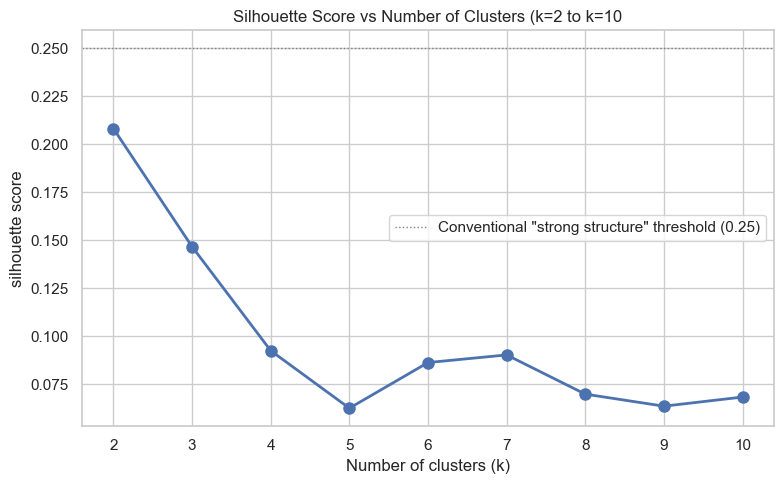

In [24]:
#Here we produce gthe figure to see the results

fig, ax = plt.subplots(figsize=(8,5))
ax.plot([r['k'] for r in k_sweep_results], [r['silhouette'] for r in k_sweep_results],
        marker='o', color='#4C72B0', linewidth=2, markersize=8)
ax.axhline(0.25, color='gray', linestyle=':', linewidth=1, label='Conventional "strong structure" threshold (0.25)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('silhouette score')
ax.set_title('Silhouette Score vs Number of Clusters (k=2 to k=10')
ax.set_xticks(range(2,11))
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_vs_k.png', dpi=150)
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


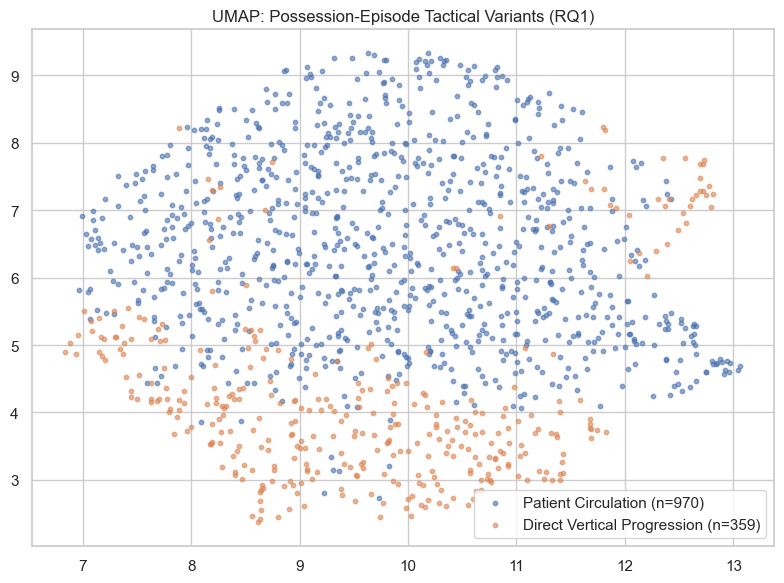

In [25]:
#Now we will produce some visulaisations using UMAP

cluster_labels = {0: 'Patient Circulation', 1: 'Direct Vertical Progression'}
feature_df['cluster_label'] = feature_df['cluster'].map(cluster_labels)

!pip install umap-learn
import umap
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.2)
embedding = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {'Patient Circulation': '#4C72B0', 'Direct Vertical Progression': '#DD8452'}
for label, color in colors.items():
    mask = feature_df['cluster_label'] == label
    ax.scatter(embedding[mask, 0], embedding[mask, 1], s=10, alpha=0.6, c=color, label=f'{label} (n={mask.sum()})')
ax.set_title('UMAP: Possession-Episode Tactical Variants (RQ1)')
ax.legend()
plt.tight_layout()
plt.savefig('umap_rq1_clusters.png', dpi=150)
plt.show()

### Pitch Visualization of Cluster Networks (RQ1)

For each cluster, the average role-to-role passing network is computed (mean adjacency matrix across all episodes in that cluster, normalized to proportions for fair visual comparison) and rendered onto a pitch diagram, with role nodes positioned at their reference-template pitch coordinates. Edge thickness reflects relative pass frequency between roles (top 12 edges shown per cluster, for clarity); node size reflects each role's total involvement (in-degree + out-degree).

In [26]:
#In the following code block we recompute each episode's raw 11x11 role adjacency matrix
#then averages these matrices separately within each cluster, normalizing so both clusters
#are on a comparable scale despite their different sizes (970 vs 359 episodes)

raw_vectors = {}

final_episodes = clean_episodes.merge(feature_df[['episode_id', 'cluster']], on='episode_id')
print(f"Final episodes with cluster labels: {len(final_episodes)}")

for match_id, match_eps in final_episodes.groupby('matchId'):
    match_action_events = events[
    (events['matchId'] == match_id) & (events['teamId'] == team_id) &
    (events['eventName'].isin(ACTION_EVENTS))
    ].sort_values(['matchPeriod', 'eventSec']).reset_index(drop=True)
    match_roles = role_assignments[role_assignments['matchId'] == match_id]

    for _, ep in match_eps.iterrows():
        seg_roles = match_roles[match_roles['segment_id'] == ep['segment_id']]
        role_map = dict(zip(seg_roles['playerId'], seg_roles['role']))
        G = build_episode_network(ep, match_action_events, role_map)
        raw_vectors[ep['episode_id']] = network_to_vector(G)

final_episodes['raw_vector'] = final_episodes['episode_id'].map(raw_vectors)

cluster_matrices = {}
for c in [0, 1]:
    vecs = np.stack(final_episodes[final_episodes['cluster'] == c]['raw_vector'].values)
    avg_matrix = vecs.mean(axis=0).reshape(11, 11)
    cluster_matrices[c] = avg_matrix / avg_matrix.sum()

Final episodes with cluster labels: 1329


In [27]:
#Now in this code block we create the pitch drawing and plotting functions

from matplotlib.patches import Rectangle

ROLE_COORDS = {
    'Goalkeeper': (5, 50),
    'Defence-Left': (20, 12),
    'Defence-CentreLeft': (20, 38),
    'Defence-CentreRight': (20, 62),
    'Defence-Right': (20, 85),
    'Midfield-Left': (50, 20),
    'Midfield-Centre': (50, 50),
    'Midfield-Right': (50, 80),
    'Attack-Left': (80, 20),
    'Attack-Centre': (80, 50),
    'Attack-Right': (80, 80),
}

def draw_pitch(ax):
    ax.set_facecolor('#2d5a3d')
    ax.add_patch(Rectangle((0, 0), 100, 100, fill=False, color='white', lw=1.5))
    ax.plot([50, 50], [0, 100], color='white', lw=1.5)
    ax.add_patch(plt.Circle((50, 50), 9, fill=False, color='white', lw=1.5))
    ax.add_patch(Rectangle((0, 21), 16, 58, fill=False, color='white', lw=1.5))
    ax.add_patch(Rectangle((84, 21), 16, 58, fill=False, color='white', lw=1.5))
    ax.set_xlim(-3, 103)
    ax.set_ylim(-3, 103)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

def plot_cluster_network(ax, matrix, title, top_n=12):
    draw_pitch(ax)
    edges = [(r1, r2, matrix[i, j]) for i, r1 in enumerate(ROLE_NODES) 
             for j, r2 in enumerate(ROLE_NODES) if i != j and matrix[i, j] > 0]
    edges.sort(key=lambda e: -e[2])
    top_edges = edges[:top_n]
    max_w = max(w for _, _, w in top_edges)

    for r1, r2, w in top_edges:
        x1, y1 = ROLE_COORDS[r1]
        x2, y2 = ROLE_COORDS[r2]
        ax.plot([x1, x2], [y1, y2], color='yellow', alpha=0.7,
                 linewidth=1 + 6 * (w / max_w), zorder=2, solid_capstyle='round')

    node_weight = matrix.sum(axis=0) + matrix.sum(axis=1)
    max_node = node_weight.max()
    for i, role in enumerate(ROLE_NODES):
        x, y = ROLE_COORDS[role]
        size = 300 + 900 * (node_weight[i] / max_node)
        ax.scatter([x], [y], s=size, color='white', edgecolor='black', zorder=3)
        short_label = (role.replace('Defence', 'DF').replace('Midfield', 'MF')
                           .replace('Attack', 'AT').replace('Goalkeeper', 'GK'))
        ax.annotate(short_label, (x, y), ha='center', va='center', fontsize=7, fontweight='bold', zorder=4)

    ax.set_title(title, fontsize=12, fontweight='bold')

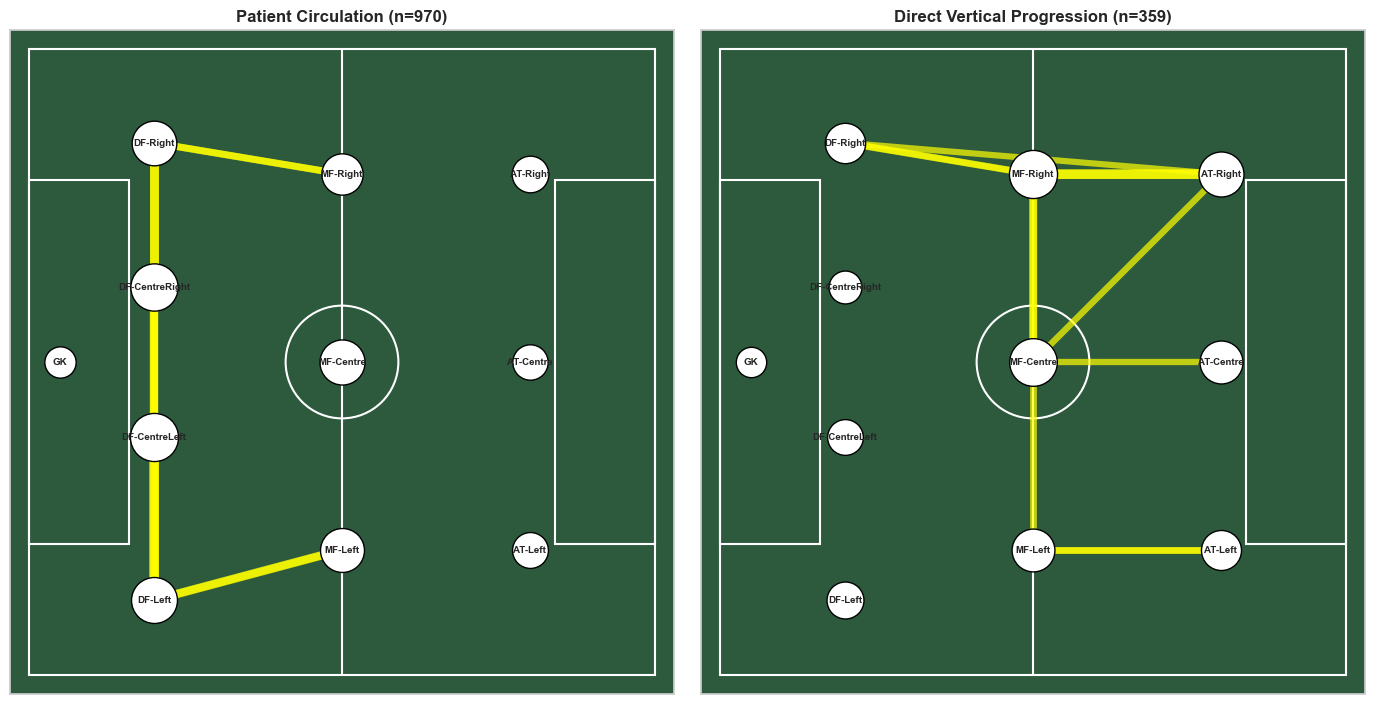

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plot_cluster_network(axes[0], cluster_matrices[0], 'Patient Circulation (n=970)')
plot_cluster_network(axes[1], cluster_matrices[1], 'Direct Vertical Progression (n=359)')
plt.tight_layout()
plt.savefig('pitch_diagrams.png', dpi=150, facecolor='white')
plt.show()

## RQ2: Tactical Variant Dynamics Across the Season

Each match is summarised by the proportion of its episodes classified as "Direct Vertical Progression" (the remainder being "Patient Circulation"). This proportion is related to contextual factors - opponent strength (proxied by the opponent's final league points) and venue - and its week-to-week volatility is compared against a smoothed trend to assess whether variant usage changes gradually or abruptly across the season.

In [29]:
#The following code block builds a match-by-match table combining the chronological context and opponent 
#identity, each match's proportion of "Direct Vertical Progression" episodes, and a lookup of the final
#2017/18 league standings

FINAL_STANDINGS_POINTS = {
    'Manchester City': 100, 'Manchester United': 81, 'Tottenham Hotspur': 77, 'Liverpool': 75,
    'Chelsea': 70, 'Arsenal': 63, 'Burnley': 54, 'Everton': 49, 'Leicester City': 47,
    'Newcastle United': 44, 'Crystal Palace': 44, 'AFC Bournemouth': 44, 'West Ham United': 42,
    'Watford': 41, 'Brighton & Hove Albion': 40, 'Huddersfield Town': 37, 'Southampton': 36,
    'Swansea City': 33, 'Stoke City': 33, 'West Bromwich Albion': 31,
}

match_context = []

#Now we build the id_to_team to have a lookup dictionary mapping each team's numeric ID
#to its name, using the teams DataFrame.
id_to_team = dict(zip(teams['wyId'], teams['name']))
raw_matches = load_raw_matches(competition=COMPETITION)

for m in raw_matches:
    if str(team_id) not in m['teamsData']:
        continue
    team_data = m['teamsData'][str(team_id)]
    opponent_id = [tid for tid in m['teamsData'].keys() if tid != str(team_id)][0]
    match_context.append({
        'matchId': m['wyId'], 'date': m.get('dateutc'),
        'venue_side': team_data.get('side'), 'team_score': team_data.get('score'),
        'opponent_name': id_to_team.get(int(opponent_id)),
        'opponent_score': m['teamsData'][opponent_id].get('score'),
    })

match_context = pd.DataFrame(match_context).sort_values('date').reset_index(drop=True)
match_context['matchweek_order'] = range(1, len(match_context) + 1)

match_summary = final_episodes.groupby('matchId')['cluster'].agg(
    n_episode='count', pct_direct=lambda x: (x == 1).mean(),
).reset_index()
match_summary.columns = ['matchId', 'n_episodes', 'pct_direct']

rq2_df = match_context.merge(match_summary, on='matchId')
rq2_df['opponent_points'] = rq2_df['opponent_name'].map(FINAL_STANDINGS_POINTS)
rq2_df['result'] = np.where(rq2_df['team_score'] > rq2_df['opponent_score'], 'W',
                            np.where(rq2_df['team_score'] == rq2_df['opponent_score'], 'D', 'L'))

print(rq2_df[['matchweek_order','opponent_name','opponent_points','venue_side','result','pct_direct']])

    matchweek_order           opponent_name  opponent_points venue_side  \
0                 1  Brighton & Hove Albion               40       away   
1                 2                 Everton               49       home   
2                 3         AFC Bournemouth               44       away   
3                 4               Liverpool               75       home   
4                 5                 Watford               41       away   
5                 6          Crystal Palace               44       home   
6                 7                 Chelsea               70       away   
7                 8              Stoke City               33       home   
8                 9                 Burnley               54       home   
9                10    West Bromwich Albion               31       away   
10               11                 Arsenal               63       home   
11               12          Leicester City               47       away   
12               13      

In [30]:
from scipy import stats

corr, pval = stats.pearsonr(rq2_df['opponent_points'], rq2_df['pct_direct'])
print(f"Opponent strength correlation: r={corr:.3f}, p={pval:.3f}")

t_stat, t_pval = stats.ttest_ind(
    rq2_df[rq2_df['venue_side'] == 'home']['pct_direct'],
    rq2_df[rq2_df['venue_side'] == 'away']['pct_direct']
)
print(f"Venue effect: t={t_stat:.3f}, p={t_pval:.3f}")

rq2_df = rq2_df.sort_values('matchweek_order').reset_index(drop=True)
rq2_df['rolling_avg'] = rq2_df['pct_direct'].rolling(window=3, center=True, min_periods=1).mean()
raw_vol = rq2_df['pct_direct'].diff().abs().mean()
smoothed_vol = rq2_df['rolling_avg'].diff().abs().mean()
print(f"Raw week-to-week volatility: {raw_vol:.3f}")
print(f"Rolling-average volatility: {smoothed_vol:.3f}")

Opponent strength correlation: r=0.351, p=0.031
Venue effect: t=-0.048, p=0.962
Raw week-to-week volatility: 0.129
Rolling-average volatility: 0.047


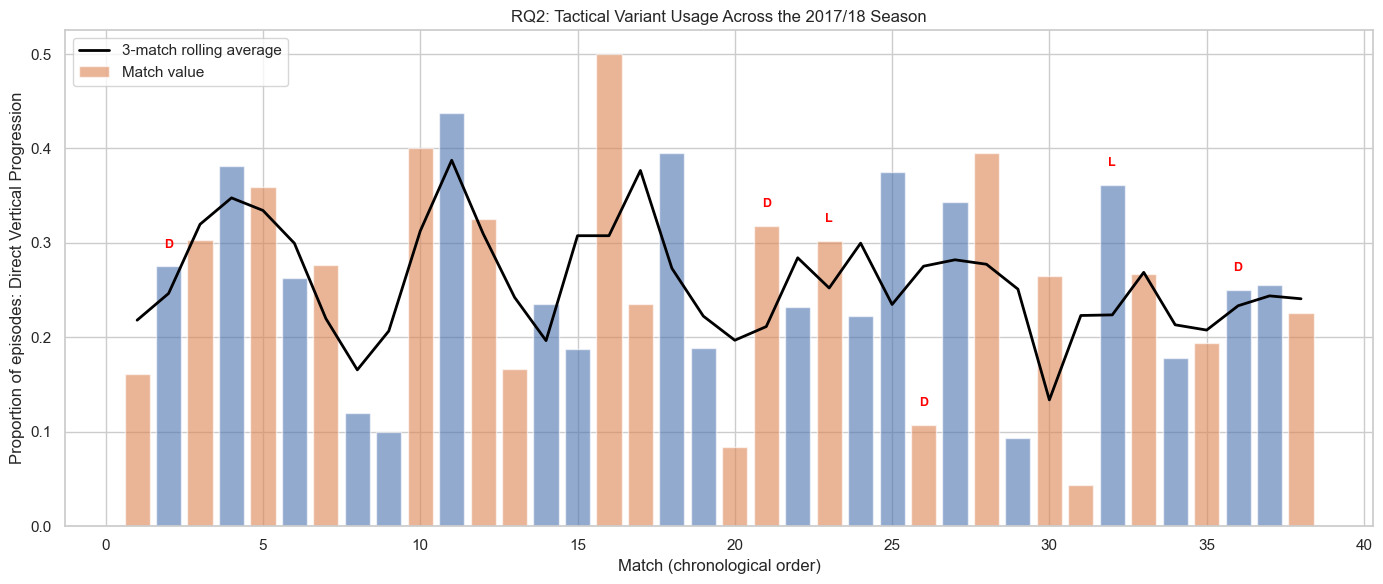

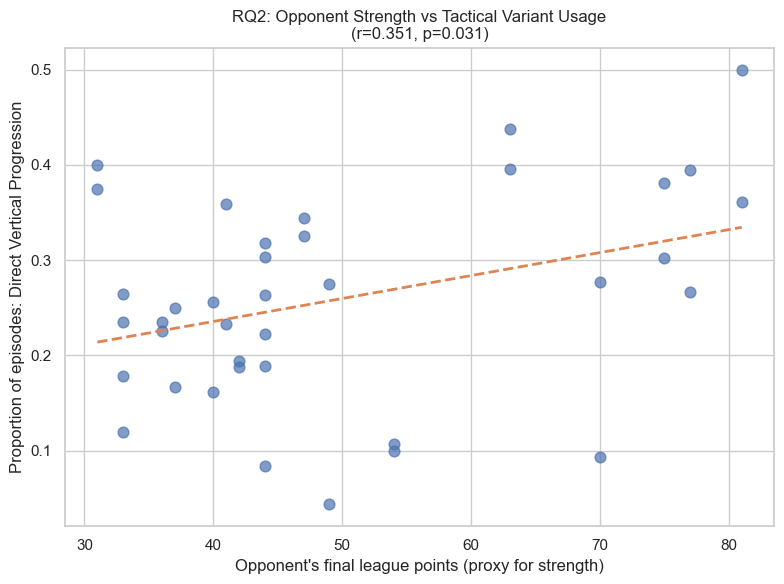

In [31]:
#Now we will create the two visuals

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#4C72B0' if v == 'home' else '#DD8452' for v in rq2_df['venue_side']]
ax.bar(rq2_df['matchweek_order'], rq2_df['pct_direct'], color=colors, alpha=0.6, label='Match value')
ax.plot(rq2_df['matchweek_order'], rq2_df['rolling_avg'], color='black', linewidth=2, label='3-match rolling average')
for _, row in rq2_df.iterrows():
    if row['result'] != 'W':
        ax.annotate(row['result'], (row['matchweek_order'], row['pct_direct'] + 0.02),
                    ha='center', fontsize=9, fontweight='bold', color='red')
ax.set_xlabel('Match (chronological order)')
ax.set_ylabel('Proportion of episodes: Direct Vertical Progression')
ax.set_title('RQ2: Tactical Variant Usage Across the 2017/18 Season')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('rq2_timeline.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(rq2_df['opponent_points'], rq2_df['pct_direct'], s=60, alpha=0.7, color='#4C72B0')
slope, intercept, r, p, se = stats.linregress(rq2_df['opponent_points'], rq2_df['pct_direct'])
x_line = np.array([rq2_df['opponent_points'].min(), rq2_df['opponent_points'].max()])
ax.plot(x_line, slope * x_line + intercept, color='#DD8452', linewidth=2, linestyle='--')
ax.set_xlabel("Opponent's final league points (proxy for strength)")
ax.set_ylabel('Proportion of episodes: Direct Vertical Progression')
ax.set_title(f"RQ2: Opponent Strength vs Tactical Variant Usage\n(r={r:.3f}, p={p:.3f})")
plt.tight_layout()
plt.savefig('rq2_opponent_strength.png', dpi=150)
plt.show()

### RQ3: Tactical Variants and Match Outcomes

Match outcome is operationalised as goal difference (a continuous measure) rather than categorical win/draw/loss, given City's heavily skewed season record (32W/4D/2L) leaves little variance for a categorical outcome to explain . The relationship between tactical variant usage (proportion of Direct Vertical Progression episodes per match) and goal difference is tested directly, and via a regression controlling for opponent strength, since opponent strength was already found to relate to variant usage and plausibly also affects goal difference directly.

In [32]:
#The following code block tests the variant-outcome relationship from four angles
#(goal difference, points, goals scored, goals conceded), then runs a proper multiple
#regression of goal difference on both pct_direct and opponent_points together.

from scipy import stats
import statsmodels.api as sm

rq2_df['goal_diff'] = rq2_df['team_score'] - rq2_df['opponent_score']
rq2_df['points'] = rq2_df['result'].map({'W': 3, 'D': 1, 'L': 0})

corr_gd, p_gd = stats.pearsonr(rq2_df['pct_direct'], rq2_df['goal_diff'])
corr_pts, p_pts = stats.pearsonr(rq2_df['pct_direct'], rq2_df['points'])
corr_scored, p_scored = stats.pearsonr(rq2_df['pct_direct'], rq2_df['team_score'])
corr_conceded, p_conceded = stats.pearsonr(rq2_df['pct_direct'], rq2_df['opponent_score'])

print(f"pct_direct vs goal difference: r={corr_gd:.3f}, p={p_gd:.3f}")
print(f"pct_direct vs points earned: r={corr_pts:.3f}, p={p_pts:.3f}")
print(f"pct_direct vs goals scored: r={corr_scored:.3f}, p={p_scored:.3f}")
print(f"pct_direct vs goals conceded: r={corr_conceded:.3f}, p={p_conceded:.3f}")
print()

X = sm.add_constant(rq2_df[['pct_direct','opponent_points']])
model = sm.OLS(rq2_df['goal_diff'], X).fit()
print(model.summary())

pct_direct vs goal difference: r=0.018, p=0.916
pct_direct vs points earned: r=-0.077, p=0.647
pct_direct vs goals scored: r=0.101, p=0.548
pct_direct vs goals conceded: r=0.144, p=0.387

                            OLS Regression Results                            
Dep. Variable:              goal_diff   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.285
Date:                Tue, 15 Sep 2026   Prob (F-statistic):              0.289
Time:                        18:36:36   Log-Likelihood:                -73.239
No. Observations:                  38   AIC:                             152.5
Df Residuals:                      35   BIC:                             157.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      

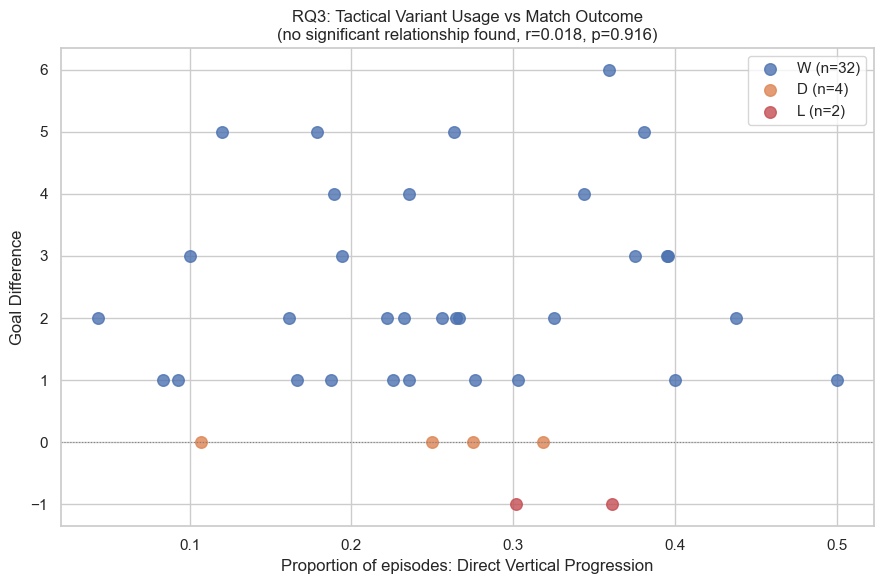

In [33]:
#Now we produce the visualisation

fig, ax = plt.subplots(figsize=(9, 6))
colors = {"W": "#4C72B0", "D": "#DD8452", "L": "#C44E52"}
for result, color in colors.items():
    subset = rq2_df[rq2_df['result'] == result]
    ax.scatter(subset['pct_direct'], subset['goal_diff'], s=70, alpha=0.8,
               color=color, label=f'{result} (n={len(subset)})')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Proportion of episodes: Direct Vertical Progression')
ax.set_ylabel('Goal Difference')
ax.set_title(f'RQ3: Tactical Variant Usage vs Match Outcome\n(no significant relationship found, r={corr_gd:.3f}, p={p_gd:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('rq3_outcome.png', dpi=150)
plt.show()